# KMeans Demo

This notebook runs the custom `KMeans` implementation on the public Iris dataset, then compares it with scikit-learn's `KMeans`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score

project_root = Path.cwd()
if not (project_root / "src" / "kmeans.py").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.kmeans import KMeans

In [2]:
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

custom_model = KMeans(n_clusters=3, init="kmeans++", max_iter=100, random_state=42)
custom_labels = custom_model.fit_predict(X)

print(f"custom inertia: {custom_model.inertia_:.4f}")
print("custom cluster sizes:", np.bincount(custom_labels, minlength=custom_model.n_clusters))

custom inertia: 78.8557
custom cluster sizes: [50 61 39]


In [3]:
sklearn_model = SklearnKMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=100,
    random_state=42,
)
sklearn_labels = sklearn_model.fit_predict(X)

print(f"sklearn inertia: {sklearn_model.inertia_:.4f}")
print("sklearn cluster sizes:", np.bincount(sklearn_labels, minlength=sklearn_model.n_clusters))

sklearn inertia: 78.8514
sklearn cluster sizes: [62 50 38]


## Result comparison

In [4]:
inertia_difference = custom_model.inertia_ - sklearn_model.inertia_
label_agreement = adjusted_rand_score(custom_labels, sklearn_labels)

print(f"custom inertia: {custom_model.inertia_:.4f}")
print(f"sklearn inertia: {sklearn_model.inertia_:.4f}")
print(f"difference: {inertia_difference:.4f}")
print(f"adjusted Rand index: {label_agreement:.4f}")

custom inertia: 78.8557
sklearn inertia: 78.8514
difference: 0.0042
adjusted Rand index: 0.9803


In [5]:
print("custom centroids:")
print(custom_model.centroids_)
print("\nsklearn centroids:")
print(sklearn_model.cluster_centers_)

custom centroids:
[[5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]
 [6.85384615 3.07692308 5.71538462 2.05384615]]

sklearn centroids:
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


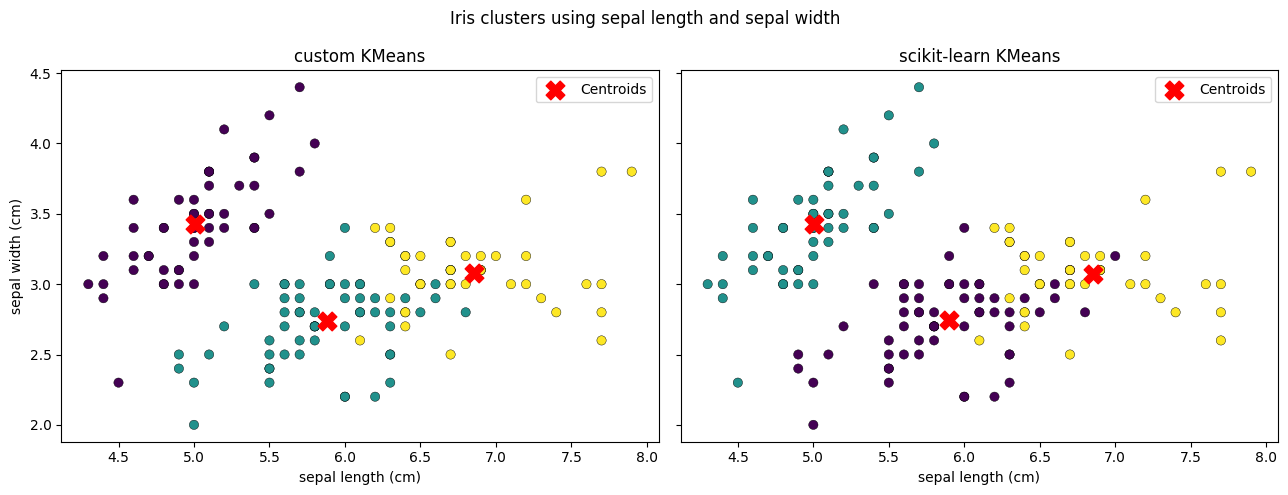

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

axes[0].scatter(X[:, 0], X[:, 1], c=custom_labels, cmap="viridis", s=45, edgecolor="k", linewidth=0.3)
axes[0].scatter(custom_model.centroids_[:, 0], custom_model.centroids_[:, 1], c="red", marker="X", s=180, label="Centroids")
axes[0].set_title("custom KMeans")
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], c=sklearn_labels, cmap="viridis", s=45, edgecolor="k", linewidth=0.3)
axes[1].scatter(sklearn_model.cluster_centers_[:, 0], sklearn_model.cluster_centers_[:, 1], c="red", marker="X", s=180, label="Centroids")
axes[1].set_title("scikit-learn KMeans")
axes[1].set_xlabel(feature_names[0])
axes[1].legend()

plt.suptitle("Iris clusters using sepal length and sepal width")
plt.tight_layout()
plt.show()